In [14]:
# uv add python-dotenv langchain langchain_google_genai
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
load_dotenv()

model = init_chat_model(
    "google_genai:gemini-2.5-flash",
    temperature = 0
)

In [15]:
from typing import TypedDict, Annotated
from langchain_core.messages import AnyMessage
from langgraph.graph import add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [16]:
from langchain_core.messages import HumanMessage

def greet(state: State):
    response = model.invoke(state['messages'])
    return {'messages': [response]}

def goodbye(state: State):
    human_message = HumanMessage(content="안녕! 잘 가!")
    response = model.invoke(state['messages'] + [human_message])
    return {'messages': [human_message, response]}

In [17]:
from langgraph.graph import StateGraph, START, END

graph_builder = StateGraph(State)

graph_builder.add_node("greet",  greet)
graph_builder.add_node("goodbye",  goodbye)

graph_builder.add_edge(START, "greet")
graph_builder.add_edge("greet", "goodbye")
graph_builder.add_edge("goodbye", END)

graph = graph_builder.compile()

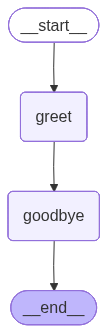

In [18]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
result = graph.invoke({"messages": HumanMessage(content="안녕, 난 김일남이야.")})

In [20]:
result

{'messages': [HumanMessage(content='안녕, 난 김일남이야.', additional_kwargs={}, response_metadata={}, id='fff78bd3-0251-47a1-b508-960ced31e25f'),
  AIMessage(content='안녕하세요, 김일남 님! 만나서 반갑습니다.\n\n저는 구글에서 훈련한 대규모 언어 모델입니다. 무엇을 도와드릴까요?', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019c7f6b-72a6-7c43-8b41-a1f4a8d549ed-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 10, 'output_tokens': 992, 'total_tokens': 1002, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 959}}),
  HumanMessage(content='안녕! 잘 가!', additional_kwargs={}, response_metadata={}, id='df4cb6b3-ad79-47de-86c3-7a2b11ecd07a'),
  AIMessage(content='네, 안녕히 가세요! 다음에 또 뵙겠습니다.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019c7f6b-888f-70